# EDA - Telecom Custumer Churn

O setor de telecomunicações apresenta alta taxa de cancelamento de cliente, tornando essencial entender por que os clientes deixam a empresa. Esta EDA tem como objetivo identificar volume, qualidade, distribuição e data readlines que influenciam o churn, analisando dados demográficos, serviços contratados, informações de cobrança e dados da conta dos clientes.

### Importando Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Carregando os Dados


In [ ]:
data = pd.read_csv('./content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
data

### Checagem dos Dados

In [ ]:
data.shape

In [ ]:
data.head()

In [ ]:
data.tail()

In [ ]:
data.columns

In [ ]:
data.dtypes

In [ ]:
# Informa dados sobre o uso de memória e valores ausentes
data.info

In [ ]:
# Colunas numéricas
num_col = data.select_dtypes(include= ['float64', 'int64'])
num_col

In [ ]:
# Colunas categóricas
cat_col = data.select_dtypes(include=['object'])
cat_col.columns

In [ ]:
# Distribuição dos dados numéricos
data.describe()

In [ ]:
# Distribuição dos dados categóricos
data.describe(include='object')

In [ ]:
# Encontrando valores unicos
# Pegando a lista de colunas categóricas, podemos utilizar um for para identificar quais colunas possuem valores unicos.
lst =['gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn']
for cat in lst:
  print(cat)
  print(f'{data[cat].unique()}\n')

In [ ]:
# Limpando os dados vazios escondidos no dataframe
# np.nan -> Substitui os espaços em branco por NaN (Not a Number) do Numpy, padrão utilizado pelo Pandas para identificar dados oficialmente Nulos
data.replace({" ":np.nan})

**TotalCharges com data type errado**

In [ ]:
# Mudando to data type de TotalChargers | Object -> Float64
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [ ]:
data.loc[:,'TotalCharges'].dtype

In [ ]:
# Checando se há duplicatas
data.duplicated().sum()

In [ ]:
# Checando se há valores vazios
data.isnull().sum()

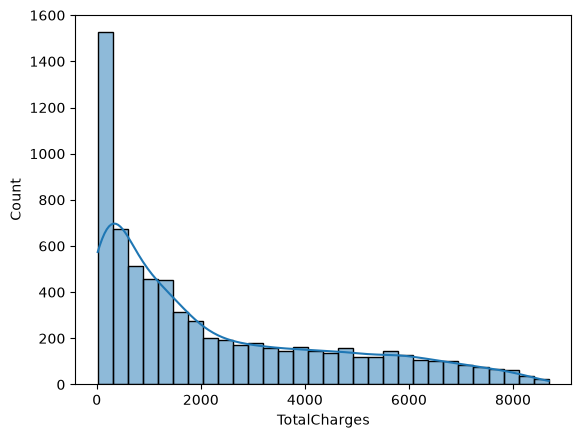

In [46]:
# Gráfico para mostrar como os valores de TotalCharges estão distribuidos
sns.histplot(data['TotalCharges'], bins=30, kde=True)
plt.show()

O gráfico mostra como os valores de TotalCharges estão distribuídos. As barras indicam quantos clientes têm valores dentro de cada faixa, e a linha (KDE) ajuda a visualizar o formato geral da distribuição.

In [ ]:
data.loc[:,'TotalCharges'].fillna(data.loc[:,'TotalCharges'].median())

Este código preenche os valores ausentes da coluna TotalCharges com a mediana da própria coluna.

# Análise dos Dados

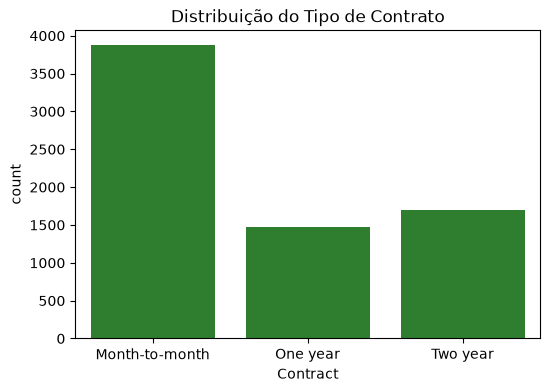

In [64]:
plt.figure(figsize=(6,4))
sns.countplot(data, x='Contract', color='forestgreen')
plt.title('Distribuição do Tipo de Contrato')
plt.show()

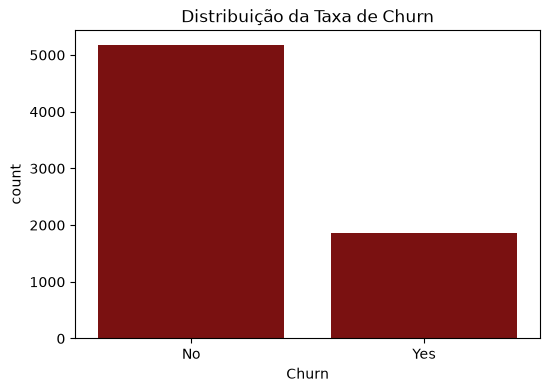

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(data, x='Churn', color='darkred')
plt.title('Distribuição da Taxa de Churn')
plt.show()

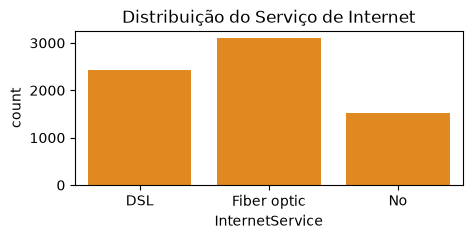

In [67]:
plt.figure(figsize=(5,2))
sns.countplot(data, x='InternetService', color='darkorange')
plt.title('Distribuição do Serviço de Internet')
plt.show()

### Insights:

* Maior parte dos clientes tem o plano de Month-to-month.
* Taxa de Churn: Uma parcela significativa de clientes cancelou o serviço (churn), o que sugere áreas de melhoria na satisfação do cliente ou na qualidade do serviço.
* 

## Hipótese 1: Tipo de contrato influencia o churn
Para testar a hipótese de que o tipo de contrato influencia o churn, comparamos a distribuição de cancelamentos entre os diferentes tipos de contrato (Contract). Utilizamos um gráfico de contagem para visualizar a quantidade de clientes que cancelaram ou não em cada tipo de contrato, além de uma tabela de proporções para avaliar a taxa de churn relativa dentro de cada grupo.

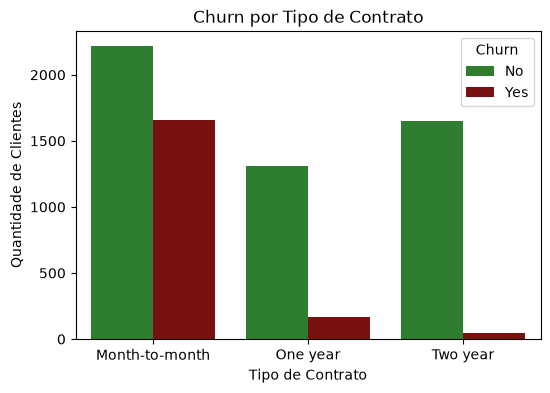

In [65]:
# Gráfico de contagem
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Contract', hue='Churn', palette=['forestgreen', 'darkred']) # hue separa as barras por quem cancelou (Yes) e quem não cancelou (No)
plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

In [ ]:
# Tabela de proporções

churn_by_contract = pd.crosstab(data['Contract'], data['Churn'], normalize='index') * 100
print(churn_by_contract)

# pd.crosstab -> cria uma tabela cruzada entre Contract e Churn.
# normalize='index' -> transforma os valores em porcentagem dentro de cada linha (ou seja, dentro de cada tipo de contrato), facilitando a comparação.
# * 100 -> converte de proporção (0 a 1) para porcentagem (0 a 100).

* Month-to-month é o único grupo onde o churn é proporcionalmente enorme. Quase a mesma quantidade de clientes que cancelou e que ficou, ou seja, praticamente 1 em cada 2 clientes desse grupo cancela o serviço.
* One/Two year têm churn muito baixo, indicando que a maioria dos clientes desses contratos permanece.